<a href="https://colab.research.google.com/github/Shiva-Kumar-S-M/Placement-Training/blob/main/Project_(Ensemble).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.4 MB/s eta 0:00:00


In [6]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
# import optuna



from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [7]:
df=pd.read_csv('/content/customer_churn_dataset-testing-master.csv')


In [8]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [9]:
df['Gender']=np.where(df['Gender']=='Female',1,0)


In [10]:
X=df.drop(['Subscription Type','Churn','Contract Length'],axis=1)
y=df['Churn']

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
rf=RandomForestClassifier().fit(X_train,y_train)
rf_pred=rf.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,rf_pred))
print("Classification Report: \n",classification_report(y_test,rf_pred))

Accuracy Score:  0.9798834951456311
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      6793
           1       0.99      0.97      0.98      6082

    accuracy                           0.98     12875
   macro avg       0.98      0.98      0.98     12875
weighted avg       0.98      0.98      0.98     12875



In [12]:
xgb=XGBClassifier().fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,xgb_pred))
print("Classification Report: \n",classification_report(y_test,xgb_pred))

Accuracy Score:  0.9789514563106796
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      6793
           1       0.99      0.97      0.98      6082

    accuracy                           0.98     12875
   macro avg       0.98      0.98      0.98     12875
weighted avg       0.98      0.98      0.98     12875



In [13]:
lbg=LGBMClassifier().fit(X_train,y_train)
lbg_pred=lbg.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,lbg_pred))
print("Classification Report: \n",classification_report(y_test,lbg_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 24411, number of negative: 27088
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 726
[LightGBM] [Info] Number of data points in the train set: 51499, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474009 -> initscore=-0.104057
[LightGBM] [Info] Start training from score -0.104057
Accuracy Score:  0.9817475728155339
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      6793
           1       0.99      0.97      0.98      6082

    accuracy                           0.98     12875
   macro avg       0.98      0.98      0.98     12875
weighted avg       0.98      0.98      0.98     12875



In [14]:
comparision=pd.DataFrame({
    'model':[
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'accuracy':[
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,lbg_pred)
    ]
})
print(comparision)

           model  accuracy
0  Random Forest  0.979883
1        XGBoost  0.978951
2       LightGBM  0.981748


In [15]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder()
one.fit_transform(df[['Subscription Type','Contract Length']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 128748 stored elements and shape (64374, 6)>

<Axes: >

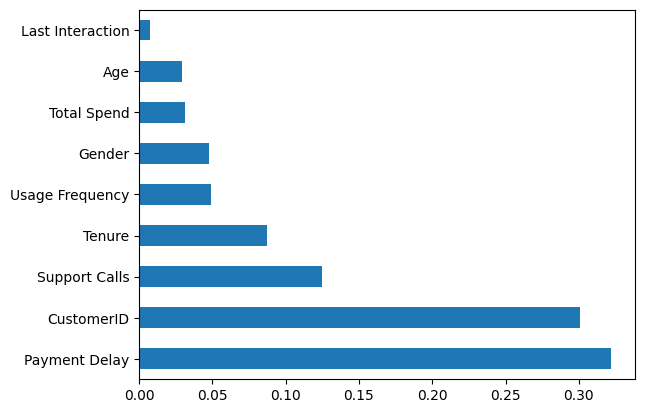

In [16]:
important=pd.Series(
    rf.feature_importances_,
    index=X.columns
)

important.sort_values(ascending=False).head(10).plot.barh()

In [17]:
precision=precision_score(y_test,rf_pred)
recall=recall_score(y_test,rf_pred)
f1=f1_score(y_test,rf_pred)

In [18]:
print("Precision Score: ",precision)
print("Recall Score: ",recall)
print("F1 Score: ",f1)

Precision Score:  0.9920567855332094
Recall Score:  0.96514304505097
F1 Score:  0.9784148679056588


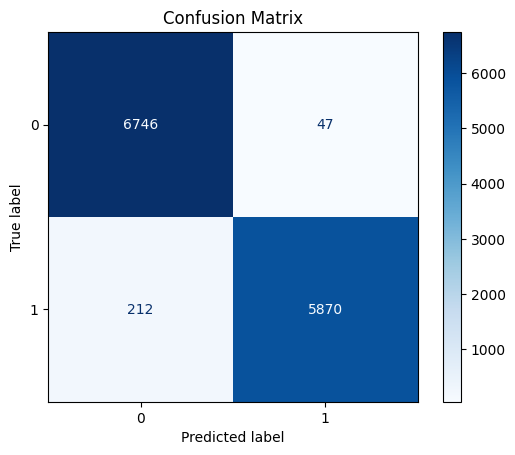

In [19]:
cm=confusion_matrix(y_test,rf_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [20]:

y_prob=rf.predict_proba(X_test)[:,1]
roc_auc_score=roc_auc_score(y_test,y_prob)
print("ROC AUC Score: ",roc_auc_score)

ROC AUC Score:  0.9987408939304552


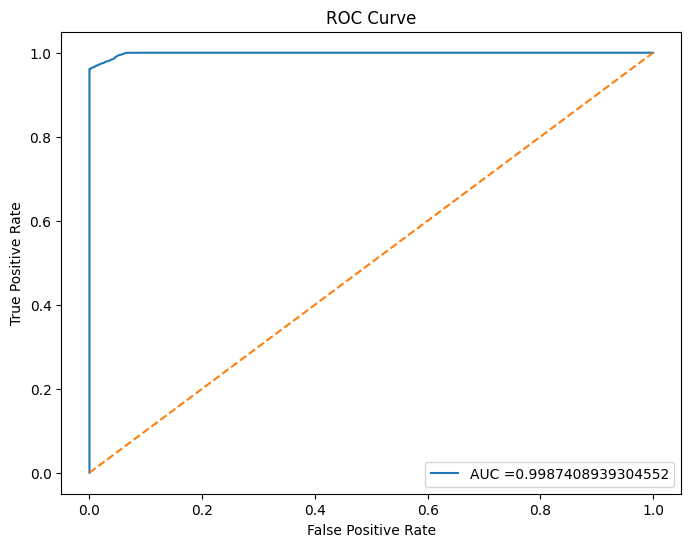

In [21]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC ={roc_auc_score}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [22]:
#1 Baseline model
# from xgboost import XGBClassifier



model=XGBClassifier(random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Baseline Accuracy :",accuracy_score(y_test,y_pred))

param_grid={
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,4,5]
}

grid=GridSearchCV(estimator=model,param_grid=param_grid,cv=5,scoring='accuracy')
grid.fit(X_train,y_train)
print("Best Parameters: ",grid.best_params_)
best_model=grid.best_estimator_
y_pred=best_model.predict(X_test)
print("Best Model Accuracy :",accuracy_score(y_test,y_pred))

Baseline Accuracy : 0.9789514563106796
Best Parameters:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Model Accuracy : 0.9820582524271845


In [23]:
random_parans={
    'n_estimators':[50,100,150,200],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'max_depth':[3,4,5,6,7]
}

random_search=RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_distributions=random_parans,
    cv=5,
    n_iter=10,
    random_state=42)
random_search.fit(X_train,y_train)
print("Best Parameters: ",random_search.best_params_)
best_random=random_search.best_estimator_
prediction=best_random.predict(X_test)
print("Best Model Accuracy :",accuracy_score(y_test,prediction))


Best Parameters:  {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
Best Model Accuracy : 0.9808932038834951


In [25]:
import optuna

In [26]:
def objective(trial):
  model=XGBClassifier(
      n_estimators=trial.suggest_int('n_estimators',100,300),
      learning_rate=trial.suggest_float('learning_rate',0.01,0.2),
      max_depth=trial.suggest_int('max_depth',3,7),
      random_state=42
  )

  model.fit(X_train,y_train)
  prediction=model.predict(X_test)
  return accuracy_score(y_test,prediction)

study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=20)
print("Best Parameters: ",study.best_params)
best_model=XGBClassifier(**study.best_params,random_state=42)
best_model.fit(X_train,y_train)
prediction=best_model.predict(X_test)
print("Best Model Accuracy :",accuracy_score(y_test,prediction))

[I 2026-07-02 08:38:18,509] A new study created in memory with name: no-name-02f892f9-2b2c-4d0d-b56b-6dbe672f611e
[I 2026-07-02 08:38:21,202] Trial 0 finished with value: 0.9801941747572815 and parameters: {'n_estimators': 224, 'learning_rate': 0.10652605567212957, 'max_depth': 5}. Best is trial 0 with value: 0.9801941747572815.
[I 2026-07-02 08:38:27,752] Trial 1 finished with value: 0.9808932038834951 and parameters: {'n_estimators': 242, 'learning_rate': 0.14314962422846764, 'max_depth': 4}. Best is trial 1 with value: 0.9808932038834951.
[I 2026-07-02 08:38:29,457] Trial 2 finished with value: 0.9797281553398058 and parameters: {'n_estimators': 131, 'learning_rate': 0.021194330690535987, 'max_depth': 6}. Best is trial 1 with value: 0.9808932038834951.
[I 2026-07-02 08:38:30,243] Trial 3 finished with value: 0.9799611650485437 and parameters: {'n_estimators': 176, 'learning_rate': 0.1003863819909008, 'max_depth': 5}. Best is trial 1 with value: 0.9808932038834951.
[I 2026-07-02 08:3

Best Parameters:  {'n_estimators': 114, 'learning_rate': 0.16589787108354265, 'max_depth': 3}
Best Model Accuracy : 0.9822135922330097
